# Nonlinear propagation using a split-step approach

In this tutorial, we'll try to simulate the propagation of an intense laser pulse through a piece of fused silica glass, and observe the influence of the dispersion and self phase modulation that the pulse experiences in the material.

This should give an overview of the functionality of the `AngularSpectrumDFFTPropagator`, the nonlinear phase applied by the `NonlinearKerrStep` and how do combine them in a simple, iterative split-step method.

First, we'll import a few relevant functions and classes:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c

from lasy.laser import Laser
from lasy.profiles import GaussianProfile
from lasy.propagators import AngularSpectrumDFFTPropagator, NonlinearKerrStep
from lasy.utils.laser_utils import get_dispersion, get_spectrum

Next, we can define key parameters of the laser pulse and use them to create a Gaussian laser profile object.

In [2]:
wavelength = 800e-9  # wavelength in meters
laser_energy = 0.5e-3  # laser pulse energy in Joule
tau = 30e-15  # pulse duration in seconds
w0 = 1e-3  # laser waist in meters
polarisation = (0, 1)  # polarisation vector of the laser
t_peak = 0  # laser peak position in time

profile = GaussianProfile(
    wavelength=wavelength,
    laser_energy=laser_energy,
    tau=tau,
    w0=w0,
    pol=polarisation,
    t_peak=t_peak,
)

To create the full laser object, we now define the parameters of the simulation grid, and combine the grid and profile to a laser object.

In [3]:
dim = "xyt"
hi = (2.5e-3, 2.5e-3, 500e-15)
lo = (-2.5e-3, -2.5e-3, -500e-15)
npoints = (100, 100, 200)

laser = Laser(dim=dim, hi=hi, lo=lo, npoints=npoints, profile=profile)

To check that the pulse looks as expected, we can show its profile

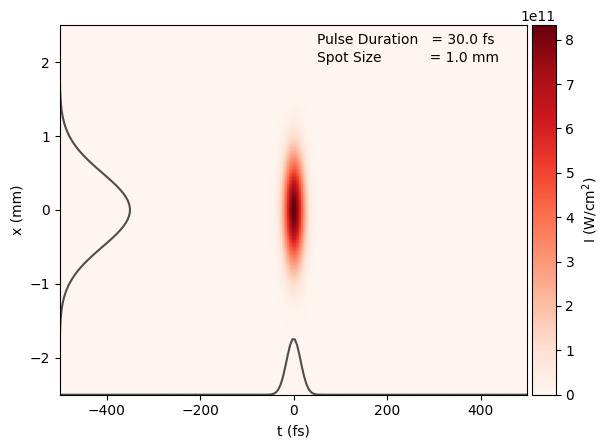

In [4]:
laser.show(show_intensity=True)

To see the influence of the self-phase modulation on the spectral properties of the laser, we can extract the initial spectrum and GDD curve of the laser pulse. 

In [5]:
initial_spectrum, omega = get_spectrum(
    grid=laser.grid, dim=laser.dim, omega0=laser.profile.omega0
)
initial_gdd, initial_gdd0 = get_dispersion(
    grid=laser.grid, dim=laser.dim, omega0=laser.profile.omega0, order=2
)

Now let's define the properties of the fused silica material that the we want the pulse to propagate in. We will need the refractive index (ideally in form of the Sellmeier equation) and the intensity dependent refractive index, $n_2$. Both taken from [refractiveindex.info](https://www.refractiveindex.info).

At this point we can also define the thickness of the fused silica window that we want to propagate through. In this example we'll use a 5mm thick window.

In [6]:
# refractive index
def n_fusedsilica(wavelength):
    """
    Sellmeier equation for fused silica
    """
    x = wavelength * 1e6  #  convert wavelength to µm
    return (
        1
        + 0.6961663 / (1 - (0.0684043 / x) ** 2)
        + 0.4079426 / (1 - (0.1162414 / x) ** 2)
        + 0.8974794 / (1 - (9.896161 / x) ** 2)
    ) ** 0.5


# intensity dependent refractive index
n2 = 2.7e-20

d_FS = 5e-3

A very common and proven approach for accurately simulating the nonlinear propagation of laser pulses is the so-called split-step method. In this method, the linear propagation, that entails effects such as dispersion and diffraction, and the non-linear propagation (containing the intensity dependent effects) into two different propagation steps. 

For our purpose, we can use the `AngularSpectrumDFFTPropagator` that describes the linear propagation in dispersive media, and the `NonlinearKerrStep` for the nonlinear propagation step. We will create them in the following:

In [7]:
linear_proapgator = AngularSpectrumDFFTPropagator(
    omega0=profile.omega0, n=n_fusedsilica, dim=laser.dim
)
nonlinear_phase = NonlinearKerrStep(n2=n2, k0=laser.profile.omega0 / c)

To accurately simulate the interplay of the two propagation steps, the split-step approach devides total propagation distance into multiple sub-steps and alternately applies the two propagation steps. In general, the simulation result will become more accurate the more propagation steps are taken. In this specific case 10 steps seems like a good compromise between accurate results and a reasonably short simulation time.

Lets to this iterative propagation next:

In [ ]:
Nsteps = 10  # number of propagation steps
dz = d_FS / Nsteps  # length of the individual propagation steps

for i in range(Nsteps):
    laser.grid = linear_proapgator.propagate(grid_in=laser.grid, distance=dz)  # linear propagation
    laser.grid = nonlinear_phase.apply(grid_in=laser.grid, distance=dz)  #  nonlinear propagation

    # print progress
    print(f"Progress: {100 * (i + 1) / Nsteps:.1f}%", end="\r")

TypeError: AngularSpectrumDFFTPropagator.propagate() missing 2 required positional arguments: 'dim' and 'omega0'

If we now again show the laser profile we can already see that the temporal shape of the pulse has changed:

In [ ]:
laser.show(show_intensity=True)

To see the effects on the spectral properties, we can again extract the spectrum and GDD curve to compare to the initial ones.

In [ ]:
output_spectrum, omega = get_spectrum(
    grid=laser.grid, dim=laser.dim, omega0=laser.profile.omega0
)
output_gdd, _ = get_dispersion(
    grid=laser.grid, dim=laser.dim, omega0=laser.profile.omega0, order=2
)

Now lets plot them for comparison

In [ ]:
wavelength_nm = 1e9 * 2 * np.pi * c / omega

# spectrum
plt.plot(wavelength_nm, initial_spectrum, label="Input spectrum")
plt.plot(wavelength_nm, output_spectrum, label="Output spectrum")
plt.ylabel("Spectral intensity")
plt.xlabel("Wavelength [nm]")
plt.ylim(
    0,
)
plt.xlim(670, 950)
plt.legend(loc="upper left")
plt.twinx()

# GDD
plt.plot(wavelength_nm, initial_gdd * 1e30, label="Input GDD", linestyle="--")
plt.plot(wavelength_nm, output_gdd * 1e30, label="Output GDD", linestyle="--")
plt.ylabel("GDD [fs$^2$]")
plt.xlabel("Wavelength [nm]")
plt.ylim(-5000, 5000)
plt.legend(loc="upper right")
plt.show()

We can clearly see how the spectrum broadens and how the phase is affected by the intensity dependent refractive index and the resulting self-phase modulation.

Finally, we can let the laser propagate in vacuum for some more distance to show the influence of the self-focusing that the pulse experiences in the fused silica. The beam size decreases and the spatial profile is deformed from the ideal Gaussian that it is intially.

In [ ]:
linStep_vacuum = AngularSpectrumDFFTPropagator(
    omega0=profile.omega0, n=1.0, dim=laser.dim
)
linStep_vacuum.propagate(grid_in=laser.grid, distance=0.2)
laser.show(show_intensity=True)